# Day 08. Exercise 04
# Regression

## 0. Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, KFold
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error

## 1. Preprocessing

1. Read the file [`checker_regression.csv`](https://drive.google.com/file/d/1L8auBzJEghWFewznhhFpcrqxW4GqcfRY/view?usp=sharing).
2. Fill the missing values in it with `0`.
3. Make a split of your dataset on train and test with parameters `test_size=0.2`.

In [2]:
df = pd.read_csv('../data/checker_regression.csv')

In [3]:
df = df.fillna(0)

In [4]:
df = df.drop('uid', axis=1)

In [5]:
df = df.drop_duplicates()

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 29 entries, 0 to 76
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   num_commits  29 non-null     int64  
 1   pageviews    29 non-null     float64
 2   AVG(diff)    29 non-null     float64
dtypes: float64(2), int64(1)
memory usage: 928.0 bytes


In [7]:
X = df.drop('AVG(diff)', axis=1)
y = df['AVG(diff)']

In [8]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=21)

## 2. Crossvalidation

1. Write a function `crossval` that takes as arguments: `n_splits` for `KFold()`, `X`, `y`, model instantiated class with the parameters of the model (keep in mind: `random_state=21`) and returns for a given model class a result like this:

```
train -  2696.4496895424836   |   test -  1589.9979527104958
train -  2660.957874001452   |   test -  2075.102636027137
train -  2847.315529246795   |   test -  320.911928168403
train -  2500.7691099659237   |   test -  4132.461382030178
train -  2643.927917295123   |   test -  2237.8140952197878
train -  2396.295678819444   |   test -  4509.650064742476
train -  2003.402267924976   |   test -  8403.491474908551
train -  2531.876094212613   |   test -  3135.944102735099
train -  2683.1795186023123   |   test -  1796.01426292594
train -  2537.1192483996338   |   test -  3439.29824116941
Average RMSE on crossval is 3164.0686140637476
```

2. Run the function for `LinearRegression`, `DecisionTreeRegressor`, `RandomForestRegressor`. You may choose the parameters by yourself, but find the good enough for you.

In [9]:
def crossval(n_splits, X, y, model):
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=21)
    test_rmses = []
    train_rmses = []
    
    for train_idx, val_idx in kf.split(X):
        X_train_fold = X.iloc[train_idx]
        y_train_fold = y.iloc[train_idx]
        X_val_fold = X.iloc[val_idx]
        y_val_fold = y.iloc[val_idx]
        
        model_clone = model.__class__(**model.get_params())
        model_clone.fit(X_train_fold, y_train_fold)
        
        y_train_pred = model_clone.predict(X_train_fold)
        y_val_pred = model_clone.predict(X_val_fold)
        
        train_rmse = np.sqrt(mean_squared_error(y_train_fold, y_train_pred))
        test_rmse = np.sqrt(mean_squared_error(y_val_fold, y_val_pred))
        train_rmses.append(train_rmse)
        test_rmses.append(test_rmse)
        
        print(f"train - {train_rmse:.4f}   |   test - {test_rmse:.4f}")
    
    avg_test_rmse = np.mean(test_rmses)
    print(f"Average RMSE on crossval is {avg_test_rmse:.4f}\n")
    return avg_test_rmse

In [10]:
models = {
    'LinearRegression': LinearRegression(),
    'DecisionTreeRegressor': DecisionTreeRegressor(max_depth=5, random_state=21),
    'RandomForestRegressor': RandomForestRegressor(n_estimators=100, max_depth=10, random_state=21)
}

In [11]:
print("Cross‑validation results (10 folds):")
for name, model in models.items():
    print(f"\n--- {name} ---")
    crossval(10, X_train, y_train, model)

Cross‑validation results (10 folds):

--- LinearRegression ---
train - 53.3335   |   test - 115.2394
train - 62.4099   |   test - 69.3581
train - 64.7515   |   test - 52.3954
train - 64.0409   |   test - 78.1881
train - 63.5741   |   test - 58.6696
train - 65.4015   |   test - 32.1007
train - 64.4060   |   test - 48.5932
train - 61.2155   |   test - 82.4173
train - 64.6937   |   test - 43.8116
train - 62.8020   |   test - 70.4723
Average RMSE on crossval is 65.1246


--- DecisionTreeRegressor ---
train - 2.4903   |   test - 43.2002
train - 18.5286   |   test - 77.3831
train - 15.4292   |   test - 9.0933
train - 15.2522   |   test - 8.6031
train - 3.0709   |   test - 80.2566
train - 15.2522   |   test - 15.2028
train - 8.5168   |   test - 40.5879
train - 15.2522   |   test - 37.1904
train - 15.0574   |   test - 50.4874
train - 2.4303   |   test - 57.9828
Average RMSE on crossval is 41.9988


--- RandomForestRegressor ---
train - 19.8531   |   test - 76.5369
train - 22.6714   |   test - 

## 3. Predictions and evaluation

1. Make predictions for the test dataset using each of the three models with the finalized parameters.
2. Draw a plot for each of the models where the `x-axis` is the actual average difference and the `y-axis` is the prediction made by a model.
3. How would plot look like in the ideal case? Put the answer to the markdown cell in the end of the section.

In [12]:
final_models = {}
for name, model in models.items():
    final_models[name] = model.__class__(**model.get_params())
    final_models[name].fit(X_train, y_train)

In [13]:
y_pred = {}
for name, model in final_models.items():
    y_pred[name] = model.predict(X_test)

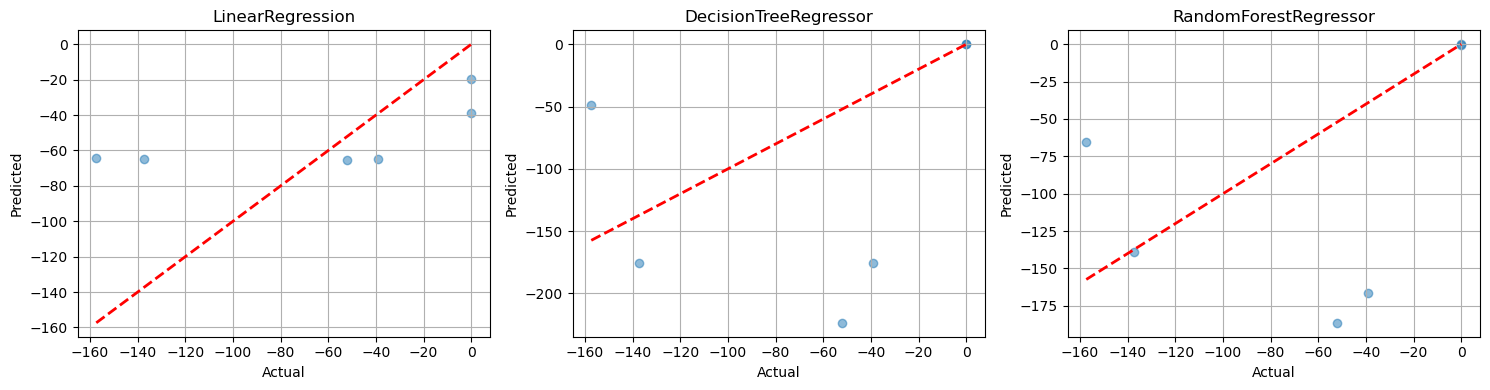

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, (name, preds) in zip(axes, y_pred.items()):
    ax.scatter(y_test, preds, alpha=0.5)
    ax.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
    ax.set_xlabel('Actual')
    ax.set_ylabel('Predicted')
    ax.set_title(name)
    ax.grid(True)
plt.tight_layout()
plt.show()

In the ideal case, the plot would show points perfectly lying on the diagonal line (y = x),
indicating that the model's predictions are exactly equal to the actual values.